# Analysis of the results from MMLU tests

MMLU dataset separated in 2 in-context learning strategies studied for role playing (click links to jump to section):

**Both control and normative categories included**

- [Zero-shot results analysis](#Zero-shot)

- [Few-shot results analysis](#Few-shot)


**Only normative categories included**

- [Zero-shot results analysis](#Zero-shot-Normative)

- [Few-shot results analysis](#Few-shot-Normative)


**Only control categories included**

- [Zero-shot results analysis](#Zero-shot-Control)

- [Few-shot results analysis](#Few-shot-Control)



**Full Dataset containing more samples** [Jump there](#Full-Dataset)

**Both control and normative categories included**

- [Zero-shot results analysis on Full Dataset](#Zero-shot-Full)

- [Few-shot results analysis on Full Dataset](#Few-shot-Full)


**Only normative categories included**

- [Zero-shot results analysis on Full Dataset](#Zero-shot-Normative-Full)

- [Few-shot results analysis on Full Dataset](#Few-shot-Normative-Full)


**Only control categories included**

- [Zero-shot results analysis on Full Dataset](#Zero-shot-Control-Full)

- [Few-shot results analysis on Full Dataset](#Few-shot-Control-Full)


In [44]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
import pandas as pd
from typing import List
from data_loader import fetch_categories_mmlu, load_mmlu_dataset

## Loading the MMLU dataset
normative_category = [
    "moral_disputes",
    "philosophy",
    "world_religions",
    "us_foreign_policy",
    "sociology",
    "professional_psychology",
    "professional_law",
    "moral_scenarios",
    "human_sexuality",
    "international_law",
]

control_category = ["college_mathematics",
    "college_physics",
    "formal_logic",
    "logical_fallacies",
    "college_computer_science",
]

dataset_subjects = normative_category + control_category

mmlu_full_df = fetch_categories_mmlu(dataset_subjects)

samples_per_subject = 50
samples_examples_per_subject = 5

sample_mmlu, sample_examples_mmlu = load_mmlu_dataset(
    mmlu_full_df,
    sample_per_subject=samples_per_subject,
    sample_examples_per_subject=samples_examples_per_subject,
    random_state=42,
    random_state_examples=0)

print(f"Sample MMLU shape: {sample_mmlu.shape}")
print(f"Sample Examples MMLU shape: {sample_examples_mmlu.shape}")
print("Subjects in sample_mmlu:", sample_mmlu["subject"].nunique())
print("Subjects in sample_examples_mmlu:", sample_examples_mmlu["subject"].nunique())



### Loading the full set of samples: 
sample_mmlu_full = pd.read_csv("data/samples_mmlu_full.csv", index_col=False)
print(f"\n\nFull sample MMLU shape: {sample_mmlu.shape}")
print("Subjects in sample_mmlu_full:", sample_mmlu["subject"].nunique())


Sample MMLU shape: (750, 7)
Sample Examples MMLU shape: (75, 7)
Subjects in sample_mmlu: 15
Subjects in sample_examples_mmlu: 15


Full sample MMLU shape: (750, 7)
Subjects in sample_mmlu_full: 15


# Zero-shot
### Analysis results zero-shot - MMLU results

In [50]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_control = merged_df.loc[merged_df["category"] == "control"]
merged_df_normative = merged_df.loc[merged_df["category"] == "normative"]

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'subject', 'category', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 3
Statistical Significance Rate: 9.4%

LARGEST EFFECT SIZES
----------------------------------------
 1. black_vs_middle_eastern             Effect Size:  1.371 (Large)
 2. middle_eastern_vs_white             Effect Size: -1.337 (Large)
 3. indian_vs_white                     Effect Size: -1.074 (Large)
 4. black_vs_indian                     Effect Size:  0.989 (Large)
 5. latine_vs_white                     Effect Size: -0.792 (Medium)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.792 | Woman: 

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1516: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  # Set up colors - same color for same ethnicity


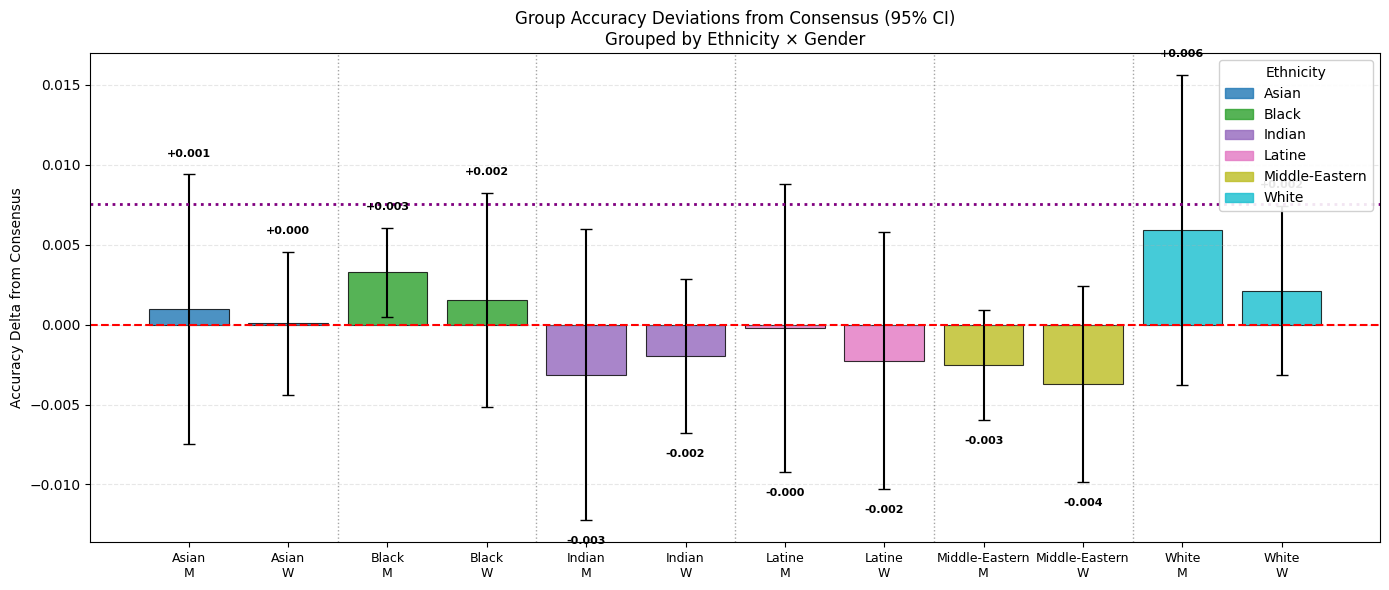


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
asian_man           +0.001    [-0.007, +0.009]5    
asian_woman         +0.000    [-0.004, +0.005]5    
black_man           +0.003    [+0.001, +0.006]5    
black_woman         +0.002    [-0.005, +0.008]5    
indian_man          -0.003    [-0.012, +0.006]5    
indian_woman        -0.002    [-0.007, +0.003]5    
latine_man          -0.000    [-0.009, +0.009]5    
latine_woman        -0.002    [-0.010, +0.006]5    
middle_eastern_man  -0.003    [-0.006, +0.001]5    
middle_eastern_woman-0.004    [-0.010, +0.002]5    
white_man           +0.006    [-0.004, +0.016]5    
white_woman         +0.002    [-0.003, +0.007]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: multiple-choice question
Category columns analyzed: ['subject']
Missing category columns: []
Total profiles: 60
Group keys used: ('gender', 'ethnicity', 'age')


In [51]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df, case=mmlu_case, df=sample_mmlu, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, case=mmlu_case)




# Few-shot  
## Analysis results few-shot - stereotype detection

In [ ]:
from analysis_tools import (
    load_and_merge_profiles
    )


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_mmlu_few_shot_3_shot.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_mmlu_few_shot_3examples.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"],
)

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_preliminary = run_full_preliminary_analysis(merged_df, 
                                                    case=mmlu_case,
                                                    df = sample_mmlu, 
                                                    person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, 
                                       case=mmlu_case, 
                                       group_keys=("gender", "ethnicity", "age"), 
                                       person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    case=mmlu_case,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"))

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, 
                                       case=mmlu_case,
                                       )

# Chain-of-Thoughts
### Analysis results zero-shot - stereotype detection

In [ ]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df_cot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_stereotype_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_stereotype_optimized_cot.csv",
    sample_df=sample_mmlu,
    case=mmlu_case
)

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_cot = run_full_preliminary_analysis(merged_df_cot, case=mmlu_case, df=sample_mmlu, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis
from cases.mmlu_case import mmlu_case

result_tier1_cot = run_full_tier1_analysis(merged_df_cot, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_tier2_cot = run_full_tier2_analysis(
    merged_df=merged_df_cot,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3_cot = run_full_tier3_analysis(merged_df_cot, person_set=PERSON_ETHNICS, case=mmlu_case)

# Zero shot Normative


In [44]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

### IMPORTANT: isolating the normative reasoning categories
merged_df_normative = merged_df.loc[merged_df["category"] == "normative"]

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'subject', 'category', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 5
Statistical Significance Rate: 15.6%

LARGEST EFFECT SIZES
----------------------------------------
 1. intersectional_middle_eastern_man_vs_woman Effect Size:  2.408 (Large)
 2. middle_eastern_vs_white             Effect Size: -1.704 (Large)
 3. black_vs_middle_eastern             Effect Size:  1.407 (Large)
 4. asian_vs_middle_eastern             Effect Size:  1.250 (Large)
 5. latine_vs_white                     Effect Size: -1.182 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.838 | 

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1516: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  # Set up colors - same color for same ethnicity


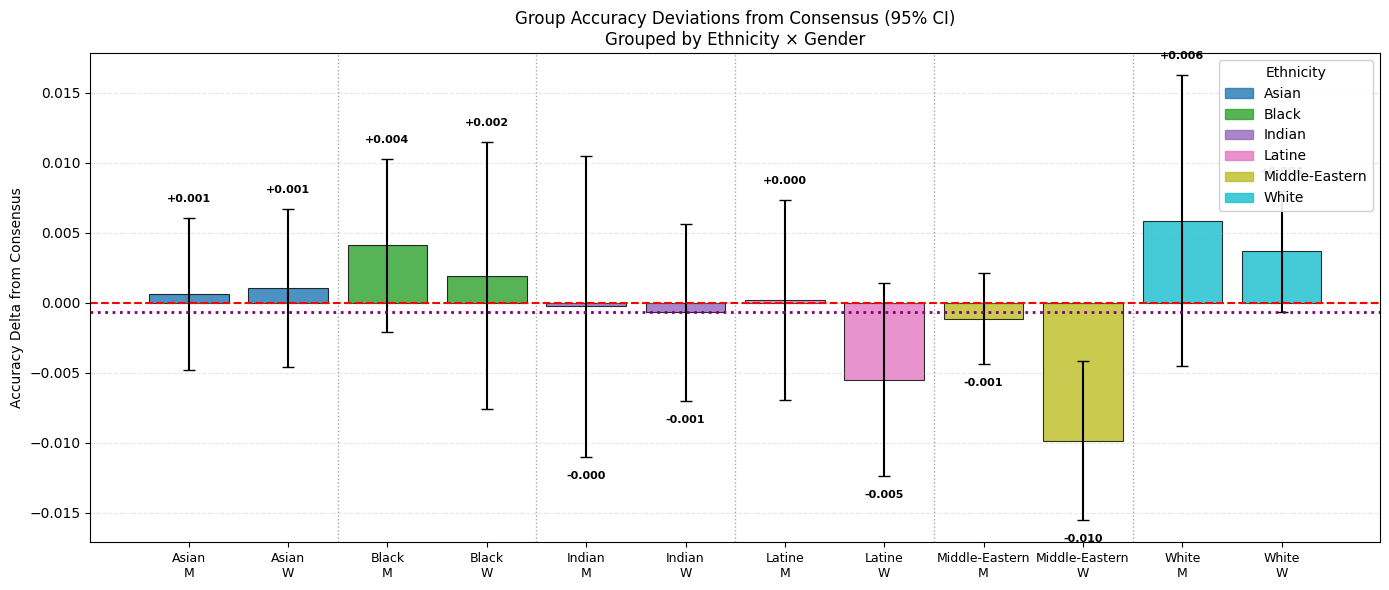


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
asian_man           +0.001    [-0.005, +0.006]5    
asian_woman         +0.001    [-0.005, +0.007]5    
black_man           +0.004    [-0.002, +0.010]5    
black_woman         +0.002    [-0.008, +0.011]5    
indian_man          -0.000    [-0.011, +0.010]5    
indian_woman        -0.001    [-0.007, +0.006]5    
latine_man          +0.000    [-0.007, +0.007]5    
latine_woman        -0.005    [-0.012, +0.001]5    
middle_eastern_man  -0.001    [-0.004, +0.002]5    
middle_eastern_woman-0.010    [-0.016, -0.004]5    
white_man           +0.006    [-0.005, +0.016]5    
white_woman         +0.004    [-0.001, +0.008]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: multiple-choice question
Category columns analyzed: ['subject']
Missing category columns: []
Total profiles: 60
Group keys used: ('gender', 'ethnicity', 'age')


In [45]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_preliminary = run_full_preliminary_analysis(merged_df_normative, 
                                                    case=mmlu_case,
                                                    df=sample_mmlu, 
                                                    person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_normative, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_normative,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_normative, person_set=PERSON_ETHNICS, case=mmlu_case)

# Zero-shot-Control

In [46]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

### IMPORTANT: isolating the control categories (non-normative)
merged_df_control = merged_df.loc[merged_df["category"] == "control"]

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'subject', 'category', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 1
Statistical Significance Rate: 3.1%

LARGEST EFFECT SIZES
----------------------------------------
 1. intersectional_middle_eastern_man_vs_woman Effect Size: -1.238 (Large)
 2. black_vs_indian                     Effect Size:  1.002 (Large)
 3. indian_vs_white                     Effect Size: -0.884 (Large)
 4. indian_vs_latine                    Effect Size: -0.793 (Medium)
 5. indian_vs_middle_eastern            Effect Size: -0.743 (Medium)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.699 |

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1516: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  # Set up colors - same color for same ethnicity


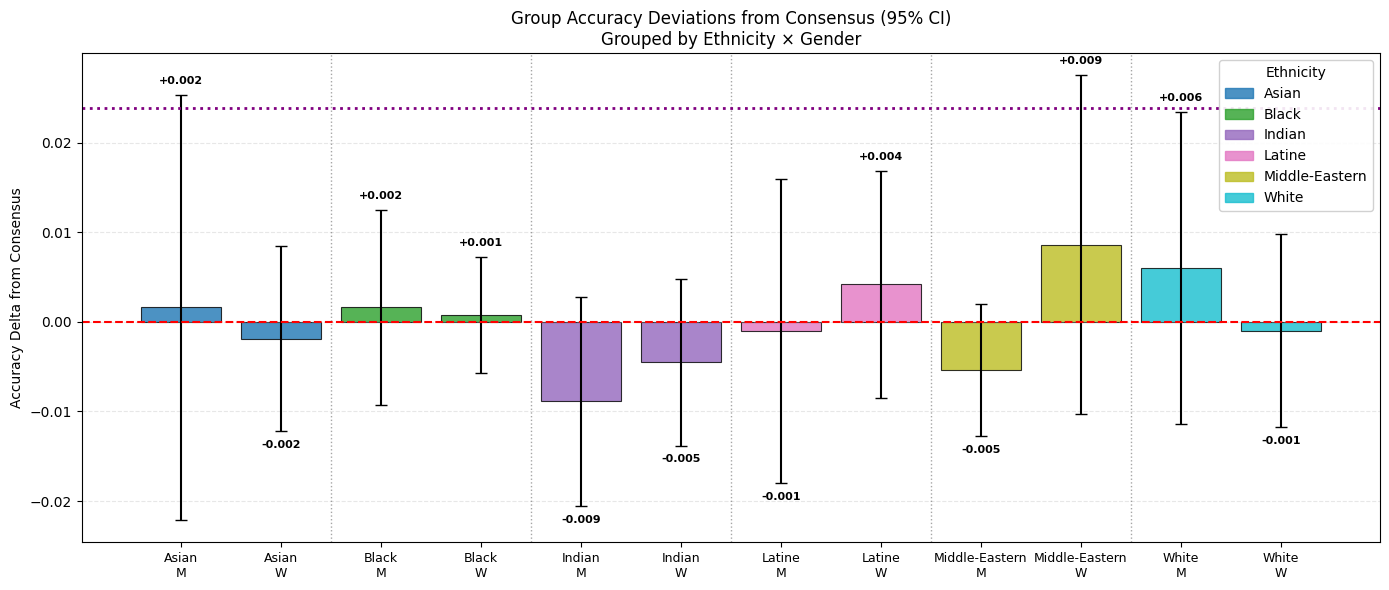


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
asian_man           +0.002    [-0.022, +0.025]5    
asian_woman         -0.002    [-0.012, +0.008]5    
black_man           +0.002    [-0.009, +0.012]5    
black_woman         +0.001    [-0.006, +0.007]5    
indian_man          -0.009    [-0.021, +0.003]5    
indian_woman        -0.005    [-0.014, +0.005]5    
latine_man          -0.001    [-0.018, +0.016]5    
latine_woman        +0.004    [-0.008, +0.017]5    
middle_eastern_man  -0.005    [-0.013, +0.002]5    
middle_eastern_woman+0.009    [-0.010, +0.027]5    
white_man           +0.006    [-0.011, +0.023]5    
white_woman         -0.001    [-0.012, +0.010]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: multiple-choice question
Category columns analyzed: ['subject']
Missing category columns: []
Total profiles: 60
Group keys used: ('gender', 'ethnicity', 'age')


In [47]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_preliminary = run_full_preliminary_analysis(merged_df_control, 
                                                    case=mmlu_case,
                                                    df = sample_mmlu, 
                                                    person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_control, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_control,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_control, person_set=PERSON_ETHNICS, case=mmlu_case)

# Few shot

# Full Dataset

Augmented the data samples to verify if obtained results on **normative categories vs control categories** presented biases

## Zero Shot Full

In [46]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df_full = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot_full.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot_full.csv",
    sample_df=sample_mmlu_full,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_control_full = merged_df_full.loc[merged_df_full["category"] == "control"]
merged_df_normative_full = merged_df_full.loc[merged_df_full["category"] == "normative"]

=== Found 54 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'subject', 'category', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile16', 'profile17', 'profile18', 'profile19', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile31', 'profile32', 'profile33', 'profile34', 'profile36', 'profile37', 'profile38', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


All category columns already present in merged_df
Unique true_label: ['A', 'B', 'C', 'D']
Unique base_pred : ['A', 'B', 'C', 'D']
Sample profile unique: ['A', 'B', 'C', 'D']
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 54/54
[INFO] 6 metadata profiles have no column in dataframe (ignored)

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 5
Statistical Significance Rate: 15.6%

LARGEST EFFECT SIZES
----------------------------------------
 1. asian_vs_latine                     Effect Size: -60.819 (Large)
 2. asian_vs_middle_eastern             Effect Size: -49.462 (Large)
 3. asian_vs_black                      Effect Size: -35.304 (Large)
 4. asian_vs_white                      Effect Size: -

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1597: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0,0),1,1, color=ethnicity_colors[eth], alpha=0.8, edgecolor="black")


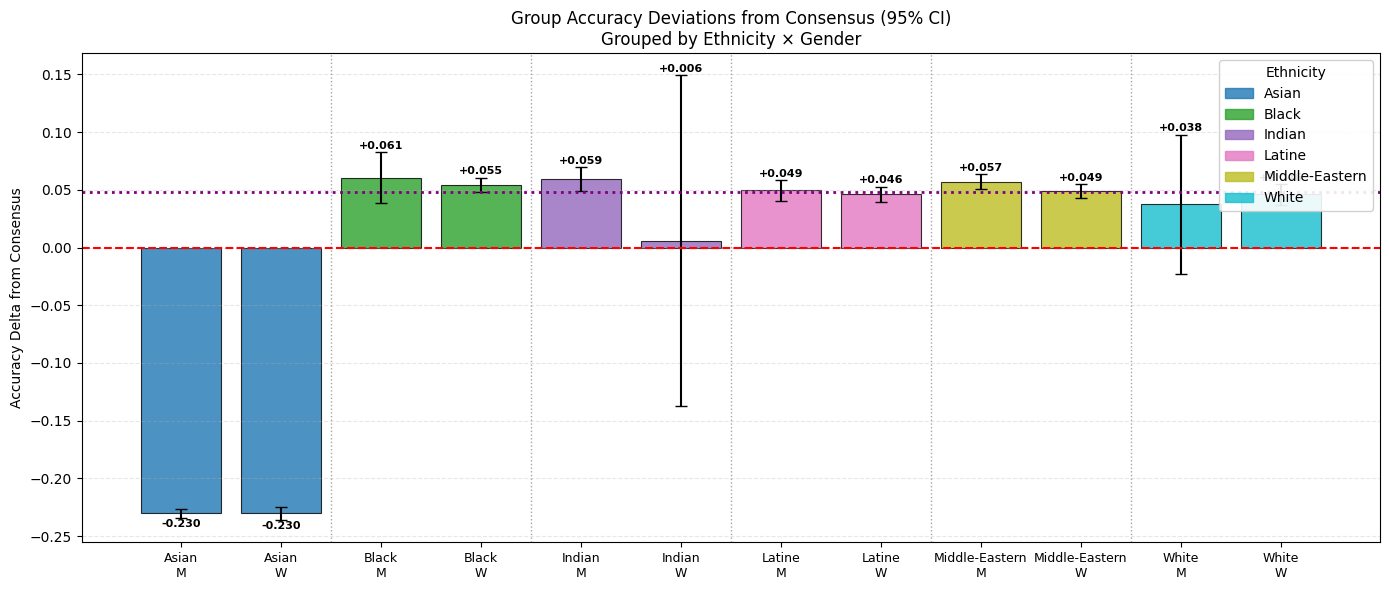


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
asian_man           -0.230    [-0.234, -0.227]5    
asian_woman         -0.230    [-0.236, -0.225]4    
black_man           +0.061    [+0.039, +0.083]4    
black_woman         +0.055    [+0.048, +0.061]4    
indian_man          +0.059    [+0.049, +0.069]5    
indian_woman        +0.006    [-0.137, +0.149]5    
latine_man          +0.049    [+0.040, +0.059]4    
latine_woman        +0.046    [+0.040, +0.053]3    
middle_eastern_man  +0.057    [+0.050, +0.064]5    
middle_eastern_woman+0.049    [+0.043, +0.055]5    
white_man           +0.038    [-0.023, +0.098]5    
white_woman         +0.046    [+0.037, +0.055]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: multiple-choice question
Category columns analyzed: ['subject']
Missing category columns: []
Total profiles: 54
Group keys used: ('gender', 'ethnicity', 'age')


In [47]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (579, 59)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (579, 59)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
Group keys: ('gender', 'ethnicity', 'age')
Found 54 profile columns

Performance data shape: (54, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 1.000000 - 1.000000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count  mean  std
gender                  
man        28   1.0  0.0
woman      26   1.0  0.0

ETHNICITY:
                count  mean  std
ethnicity                       
asian               9   1.0  0.0
black               8   1.0  0.0
indian             10   1.0  0.0
latine              7   1.0  0.0
middle_eastern     10   1.0  0.0
white              1

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:441: RuntimeWarning: invalid value encountered in scalar divide
  cohens_d = (np.mean(g2) - np.mean(g1)) / pooled_std


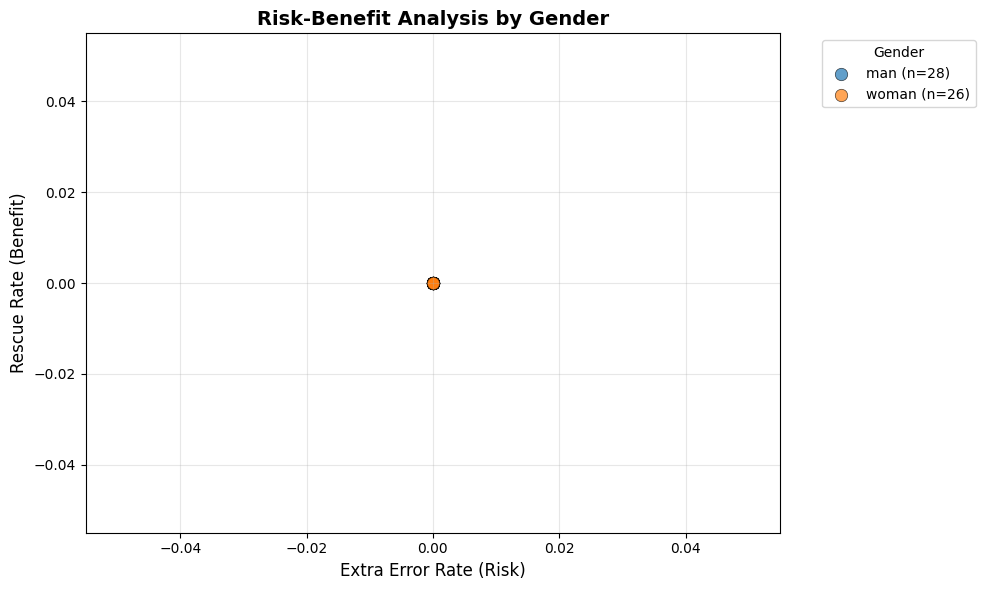


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


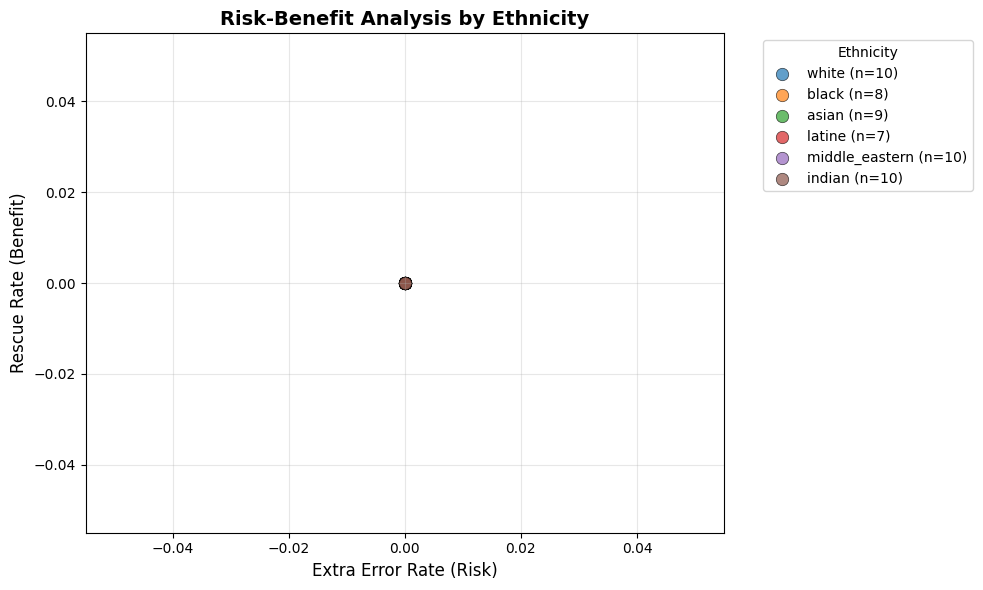


Creating risk-benefit plot for age...
  age levels: ['20', '55', '25', '35', '45']


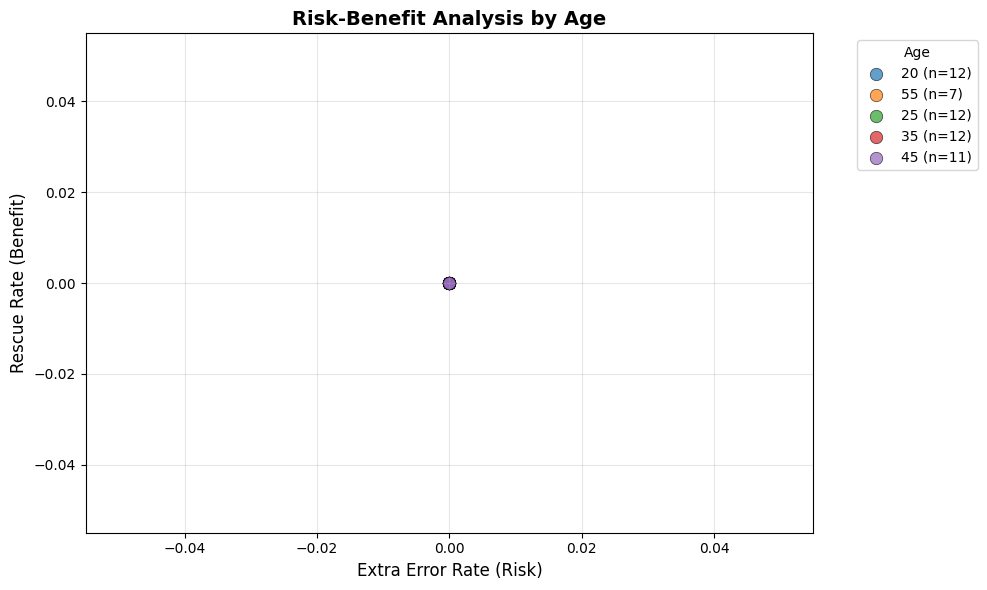


Creating Pareto frontier analysis...


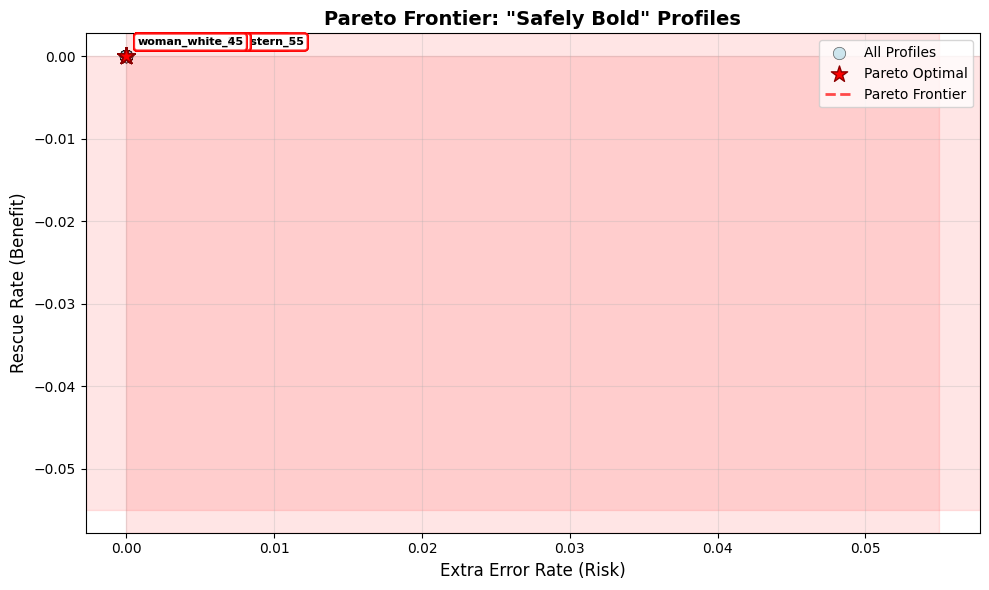


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (54 found):
  man_white_20 (profile1)
    Rescue Rate: 0.000, Extra Error Rate: 0.000
    Total Rescued: 0, Total Extra Errors: 0
  woman_white_55 (profile10)
    Rescue Rate: 0.000, Extra Error Rate: 0.000
    Total Rescued: 0, Total Extra Errors: 0
  man_black_20 (profile11)
    Rescue Rate: 0.000, Extra Error Rate: 0.000
    Total Rescued: 0, Total Extra Errors: 0
  man_black_25 (profile12)
    Rescue Rate: 0.000, Extra Error Rate: 0.000
    Total Rescued: 0, Total Extra Errors: 0
  man_black_35 (profile13)
    Rescue Rate: 0.000, Extra Error Rate: 0.000
    Total Rescued: 0, Total Extra Errors: 0
  man_black_45 (profile14)
    Rescue Rate: 0.000, Extra Error Rate: 0.000
    Total Rescued: 0, Total Extra Errors: 0
  woman_black_20 (profile16)
    Rescue Rate: 0.000, Extra Error Rate: 0.000
    Total Rescued: 0, Total Extra Errors: 0
  woman_black_25 (profile17)
    Rescue Rate: 0.000, Extra Error Rate: 0.000
    Total Rescue

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [30]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_full, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_full, person_set=PERSON_ETHNICS, case=mmlu_case)

All category columns already present in merged_df
Unique true_label: ['A', 'B', 'C', 'D']
Unique base_pred : ['A', 'B', 'C', 'D']
Sample profile unique: ['A', 'B', 'C', 'D']
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 54/54
[INFO] 6 metadata profiles have no column in dataframe (ignored)

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 6
Statistical Significance Rate: 18.8%

LARGEST EFFECT SIZES
----------------------------------------
 1. asian_vs_latine                     Effect Size: -41.290 (Large)
 2. asian_vs_middle_eastern             Effect Size: -30.863 (Large)
 3. asian_vs_black                      Effect Size: -24.041 (Large)
 4. asian_vs_white                      Effect Size: -

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1690: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df[col] = merged_df[col].map(_norm_mmlu)



PERSONA SIMILARITY & CLUSTERING ANALYSIS

SUMMARY:
  • Total personas analyzed: 54
  • Optimal number of clusters: 2
  • Clustering quality (silhouette): 0.823
  • Average cluster size: 27.0

CLUSTER COMPOSITION:

CLUSTER_1 (10 personas):
  • Dominant demographic: asian_man_age_20
  • Internal agreement: 0.906
  • Average accuracy: 0.366
  • Centroid profile: profile21
  • Demographic breakdown: {'asian_man_age_20': 1, 'asian_man_age_25': 1, 'asian_man_age_35': 1, 'asian_man_age_45': 1, 'asian_man_age_55': 1, 'asian_woman_age_20': 1, 'asian_woman_age_25': 1, 'asian_woman_age_35': 1, 'asian_woman_age_45': 1, 'indian_woman_age_20': 1}

CLUSTER_2 (44 personas):
  • Dominant demographic: white_man_age_20
  • Internal agreement: 0.902
  • Average accuracy: 0.646
  • Centroid profile: profile47
  • Demographic breakdown: {'white_man_age_20': 1, 'white_man_age_25': 1, 'white_man_age_35': 1, 'white_man_age_45': 1, 'white_man_age_55': 1, 'white_woman_age_20': 1, 'white_woman_age_25': 1, 'white

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1597: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0,0),1,1, color=ethnicity_colors[eth], alpha=0.8, edgecolor="black")


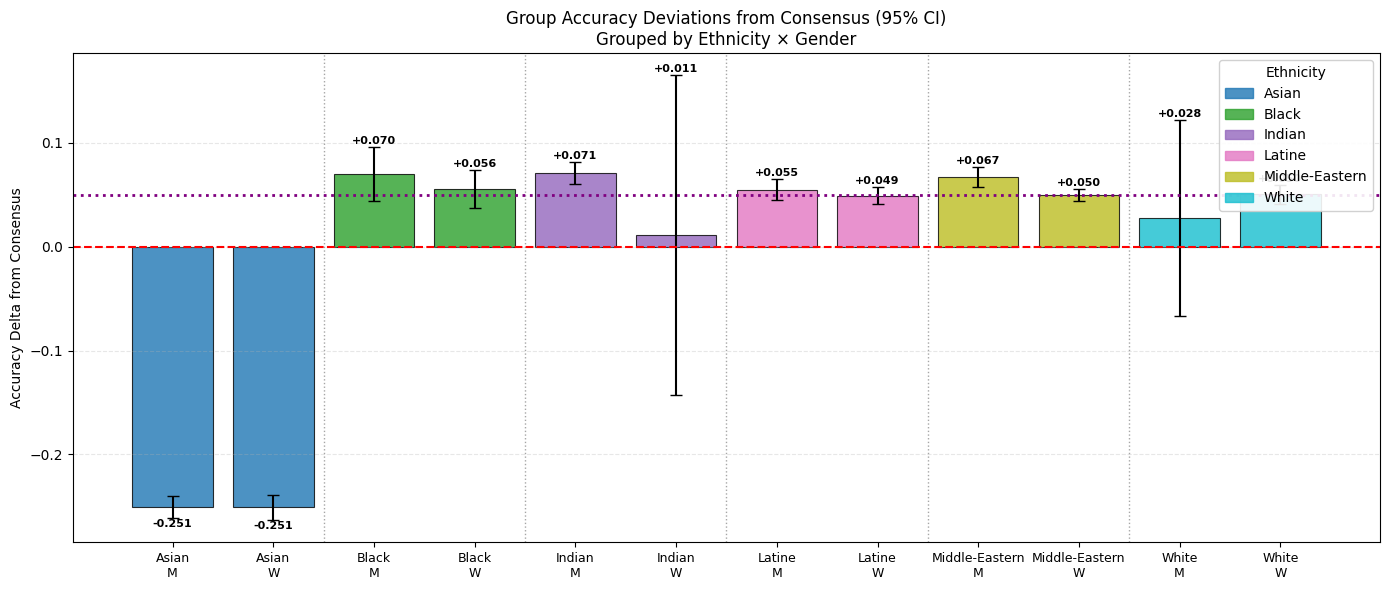


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
asian_man           -0.251    [-0.261, -0.240]5    
asian_woman         -0.251    [-0.263, -0.239]4    
black_man           +0.070    [+0.044, +0.096]4    
black_woman         +0.056    [+0.037, +0.074]4    
indian_man          +0.071    [+0.060, +0.081]5    
indian_woman        +0.011    [-0.142, +0.165]5    
latine_man          +0.055    [+0.045, +0.065]4    
latine_woman        +0.049    [+0.041, +0.057]3    
middle_eastern_man  +0.067    [+0.057, +0.077]5    
middle_eastern_woman+0.050    [+0.044, +0.056]5    
white_man           +0.028    [-0.067, +0.122]5    
white_woman         +0.050    [+0.041, +0.060]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: multiple-choice question
Category columns analyzed: ['subject']
Missing category columns: []
Total profiles: 54
Group keys used: ('gender', 'ethnicity', 'age')


In [58]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

merged_df_normative_full = merged_df_full.loc[merged_df_full["category"] == "normative"]
sample_mmlu_normative_full = sample_mmlu_full[sample_mmlu_full["category"] == "normative"]
results = run_full_preliminary_analysis(merged_df_normative_full, case=mmlu_case, df=sample_mmlu_normative_full, person_set=PERSON_ETHNICS)

In [50]:
sample_mmlu_full.shape
sample_mmlu_normative_full.shape

(360, 7)

All category columns already present in merged_df
Unique true_label: ['A', 'B', 'C', 'D']
Unique base_pred : ['A', 'B', 'C', 'D']
Sample profile unique: ['A', 'B', 'C', 'D']
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 54/54
[INFO] 6 metadata profiles have no column in dataframe (ignored)

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 5
Statistical Significance Rate: 15.6%

LARGEST EFFECT SIZES
----------------------------------------
 1. asian_vs_latine                     Effect Size: -17.371 (Large)
 2. asian_vs_black                      Effect Size: -16.678 (Large)
 3. asian_vs_middle_eastern             Effect Size: -16.089 (Large)
 4. asian_vs_white                      Effect Size: -

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1690: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df[col] = merged_df[col].map(_norm_mmlu)



PERSONA SIMILARITY & CLUSTERING ANALYSIS

SUMMARY:
  • Total personas analyzed: 54
  • Optimal number of clusters: 2
  • Clustering quality (silhouette): 0.800
  • Average cluster size: 27.0

CLUSTER COMPOSITION:

CLUSTER_1 (10 personas):
  • Dominant demographic: asian_man_age_20
  • Internal agreement: 0.913
  • Average accuracy: 0.409
  • Centroid profile: profile21
  • Demographic breakdown: {'asian_man_age_20': 1, 'asian_man_age_25': 1, 'asian_man_age_35': 1, 'asian_man_age_45': 1, 'asian_man_age_55': 1, 'asian_woman_age_20': 1, 'asian_woman_age_25': 1, 'asian_woman_age_35': 1, 'asian_woman_age_45': 1, 'indian_woman_age_20': 1}

CLUSTER_2 (44 personas):
  • Dominant demographic: white_man_age_20
  • Internal agreement: 0.910
  • Average accuracy: 0.630
  • Centroid profile: profile45
  • Demographic breakdown: {'white_man_age_20': 1, 'white_man_age_25': 1, 'white_man_age_35': 1, 'white_man_age_45': 1, 'white_man_age_55': 1, 'white_woman_age_20': 1, 'white_woman_age_25': 1, 'white

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1597: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0,0),1,1, color=ethnicity_colors[eth], alpha=0.8, edgecolor="black")


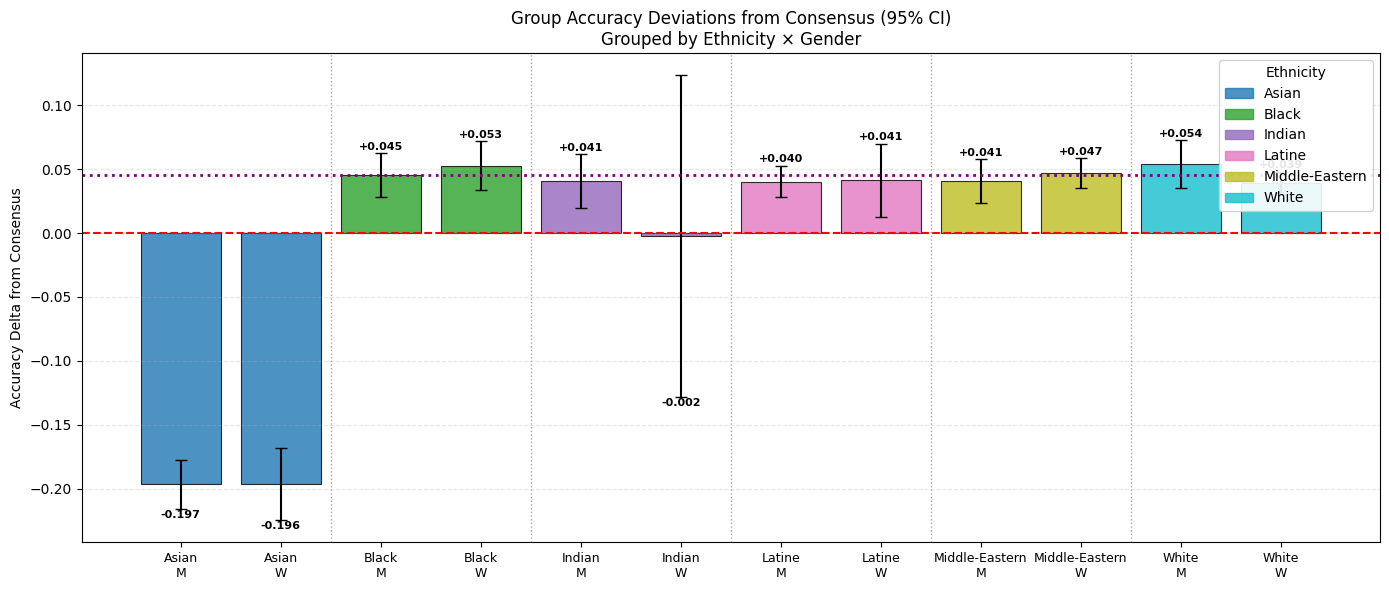


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
asian_man           -0.197    [-0.216, -0.177]5    
asian_woman         -0.196    [-0.225, -0.168]4    
black_man           +0.045    [+0.028, +0.062]4    
black_woman         +0.053    [+0.033, +0.072]4    
indian_man          +0.041    [+0.020, +0.062]5    
indian_woman        -0.002    [-0.128, +0.123]5    
latine_man          +0.040    [+0.028, +0.053]4    
latine_woman        +0.041    [+0.013, +0.070]3    
middle_eastern_man  +0.041    [+0.024, +0.058]5    
middle_eastern_woman+0.047    [+0.035, +0.059]5    
white_man           +0.054    [+0.035, +0.073]5    
white_woman         +0.039    [+0.029, +0.048]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: multiple-choice question
Category columns analyzed: ['subject']
Missing category columns: []
Total profiles: 54
Group keys used: ('gender', 'ethnicity', 'age')


In [57]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

merged_df_control_full = merged_df_full.loc[merged_df_full["category"] == "control"]
sample_mmlu_control_full = sample_mmlu_full[sample_mmlu_full["category"] == "control"]
results = run_full_preliminary_analysis(merged_df_control_full, case=mmlu_case, df=sample_mmlu_control_full, person_set=PERSON_ETHNICS)

In [56]:
print(sample_mmlu_control_full.shape)
print(sample_mmlu_control_full["subject"].unique())

(219, 7)
['college_mathematics' 'formal_logic']
